In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import DBSCAN
from sklearn.cluster import HDBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


import matplotlib.pyplot as plt

In [29]:
data = pd.read_csv('../data/students_transformed.csv').dropna()
scaler = RobustScaler()
data = scaler.fit_transform(data)
data = pd.DataFrame(data, columns=pd.read_csv('../data/students_transformed.csv').columns)


Explained variance ratio: [2.90132164e-01 1.52641425e-01 8.18248219e-02 7.57819288e-02
 5.56852381e-02 4.05747186e-02 3.25740795e-02 2.66344368e-02
 2.30292506e-02 2.12877469e-02 1.61383258e-02 1.52909997e-02
 1.35865454e-02 1.34503266e-02 1.19887181e-02 1.08309304e-02
 1.05401680e-02 9.35198812e-03 8.97615397e-03 8.41493259e-03
 7.64392798e-03 7.20353087e-03 6.42447488e-03 6.31531713e-03
 5.98135297e-03 5.62490555e-03 4.73850529e-03 4.28624491e-03
 4.14662274e-03 3.92352487e-03 3.53146040e-03 2.94421090e-03
 2.58210966e-03 2.46087234e-03 2.19922172e-03 1.99135680e-03
 1.91799863e-03 1.64289651e-03 1.12222846e-03 8.04020817e-04
 5.48375488e-04 4.67385744e-04 4.59501386e-04 3.47030755e-04
 3.11356694e-04 2.30245200e-04 2.10859310e-04 1.59927479e-04
 1.38507419e-04 1.00606776e-04 9.58919477e-05 9.27875659e-05
 8.19257983e-05 7.92572119e-05 7.42812211e-05 6.72340828e-05
 5.54308740e-05 4.34257067e-05 4.13037648e-05 3.63282405e-05
 2.83116759e-05 2.72553719e-05 2.10529380e-05 1.91289087e-0

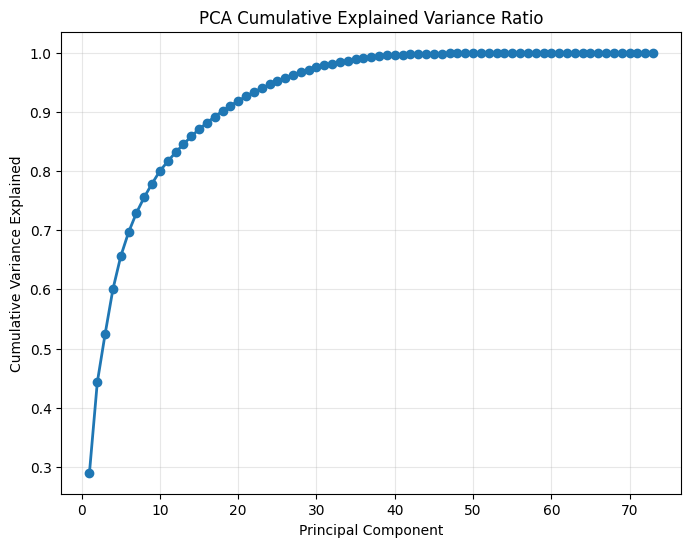

In [30]:
pca = PCA(random_state=42)
pca_results = pca.fit_transform(data.drop(columns=['final_result']))

# Print explained variance
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

train_labels = data['final_result']

# Visualize PCA components importatnce
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o', linestyle='-', linewidth=2)
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Cumulative Explained Variance Ratio')
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
train_X = PCA(n_components=18).fit_transform(data.drop(columns=['final_result']))

In [ ]:
eps_values = [round(x, 2) for x in np.linspace(1.5, num=6)]
min_samples_values = range(50, 110, 20)

results = []
index = 0
for eps in eps_values:
    for min_samples in min_samples_values:
        clusterer = make_pipeline(DBSCAN(eps=eps, min_samples=min_samples, metric='euclidean'))
        
        # Fit on training set only
        train_labels = clusterer.fit_predict(train_X)
        n_clusters_train = len(set(train_labels)) - (1 if -1 in train_labels else 0)
        n_noise_train = list(train_labels).count(-1)
        

        # scan on validation set       
        silhouette_score_val = silhouette_score(train_X, train_labels) if n_clusters_train > 1 else -1
        davies_bouldin_score_val = davies_bouldin_score(train_X, train_labels) if n_clusters_train > 1 else -1
        # calinski_harabasz_score_val = calinski_harabasz_score(train_X, train_labels) if n_clusters
        
        results.append({
            "min_samples": min_samples,
            "eps": eps,
            "n_clusters_train": n_clusters_train,
            "n_noise_train": n_noise_train,
            "silhouette_score_val": silhouette_score_val,
            "davies_bouldin_score_val": davies_bouldin_score_val
        })
        print(f"Tested s={min_samples} e={eps}-> {n_clusters_train} clusters (train), {n_noise_train} noise")
        print(f"Completed {((index+1)/(len(min_samples_values)*len(eps_values)))*100}%")
        index += 1
results_df = pd.DataFrame(results)


Tested s=50 e=0.5-> 3 clusters (train), 22815 noise
Completed 5.555555555555555%
Tested s=70 e=0.5-> 2 clusters (train), 22951 noise
Completed 11.11111111111111%
Tested s=90 e=0.5-> 2 clusters (train), 22975 noise
Completed 16.666666666666664%
Tested s=50 e=0.7-> 1 clusters (train), 22596 noise
Completed 22.22222222222222%
Tested s=70 e=0.7-> 1 clusters (train), 22611 noise
Completed 27.77777777777778%
Tested s=90 e=0.7-> 1 clusters (train), 22623 noise
Completed 33.33333333333333%
Tested s=50 e=0.9-> 1 clusters (train), 22542 noise
Completed 38.88888888888889%
Tested s=70 e=0.9-> 1 clusters (train), 22562 noise
Completed 44.44444444444444%
Tested s=90 e=0.9-> 1 clusters (train), 22562 noise
Completed 50.0%
Tested s=50 e=1.1-> 1 clusters (train), 22525 noise
Completed 55.55555555555556%
Tested s=70 e=1.1-> 1 clusters (train), 22526 noise
Completed 61.111111111111114%
Tested s=90 e=1.1-> 1 clusters (train), 22526 noise
Completed 66.66666666666666%
Tested s=50 e=1.3-> 2 clusters (train),

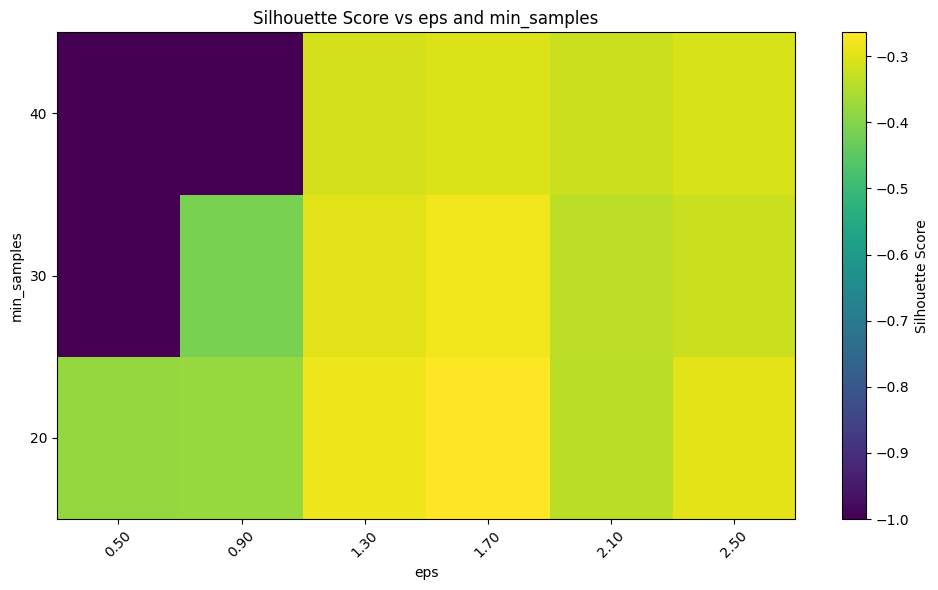

In [16]:
pivot_silhouette = results_df.pivot_table(
    values='silhouette_score_val',
    index='min_samples',
    columns='eps'
)

plt.figure(figsize=(10, 6))
plt.imshow(pivot_silhouette, aspect='auto', cmap='viridis', origin='lower')
plt.colorbar(label='Silhouette Score')
plt.xlabel('eps')
plt.ylabel('min_samples')
plt.title('Silhouette Score vs eps and min_samples')
plt.xticks(range(len(pivot_silhouette.columns)), [f'{x:.2f}' for x in pivot_silhouette.columns], rotation=45)
plt.yticks(range(len(pivot_silhouette.index)), pivot_silhouette.index)
plt.tight_layout()
plt.show()

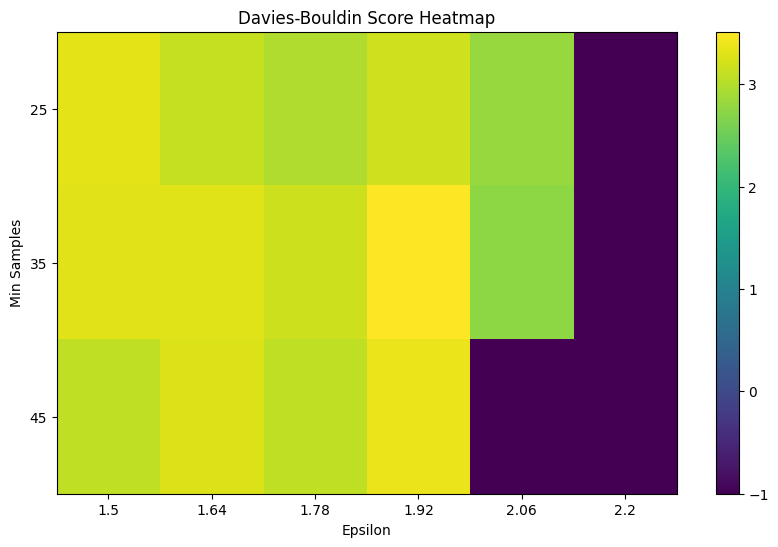

In [ ]:
pivot_davies = results_df.pivot_table(index='min_samples', columns='eps', values='davies_bouldin_score_val')

plt.figure(figsize=(10, 6))
plt.imshow(pivot_davies, cmap='viridis', aspect='auto')
plt.bar_label = plt.colorbar()
plt.title('Davies-Bouldin Score Heatmap')
plt.xlabel('Epsilon')
plt.ylabel('Min Samples')
plt.xticks(ticks=np.arange(len(pivot_davies.columns)), labels=pivot_davies.columns)
plt.yticks(ticks=np.arange(len(pivot_davies.index)), labels=pivot_davies.index)
plt.show()

In [33]:
clusterer = make_pipeline(DBSCAN(min_samples=50, eps=0.5, metric='euclidean'))
        
train_labels = clusterer.fit_predict(train_X)

In [34]:

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
tsne_results = tsne.fit_transform(train_X)


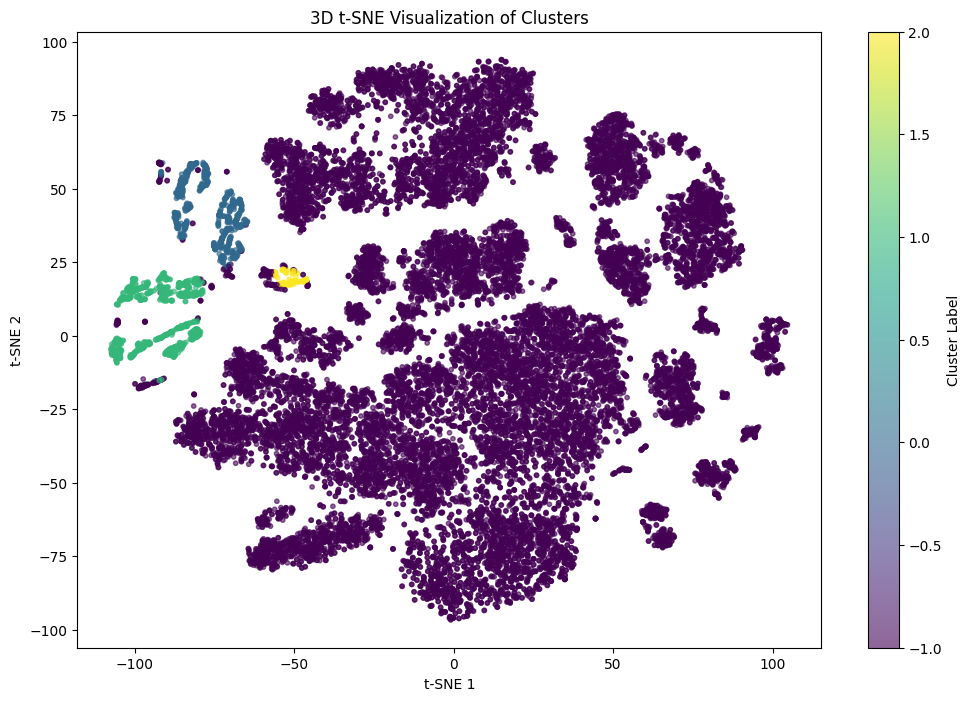

In [35]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111)

scatter = ax.scatter(tsne_results[:, 0], tsne_results[:, 1], 
                     c=train_labels, cmap='viridis', s=10, alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('3D t-SNE Visualization of Clusters')
plt.colorbar(scatter, ax=ax, label='Cluster Label')
plt.show()